# Data Processing

In [19]:
import pandas as pd
from ALLCools.clustering import one_vs_rest_dmg

In [171]:
mcds_paths = '/ceph/MethDev/pbio/gene_frac.mcds'
cell_meta_path = '/ceph/MethDev/pbio/MappingSummary.csv.gz'
cluster_path = '/ceph/MethDev/pbio/Arab6_cells_and_clusters.csv'
umap_path = '/ceph/MethDev/pbio/data/umap_coordinates.csv'
mc_path = '/ceph/MethDev/pbio/kay/data/mCGN_filtered_002.csv'
cluster_col = 'Cluster'

obs_dim = 'cell'
var_dim = 'gene'
mc_type = 'CHN'

top_n = 1000
auroc_cutoff = 0
adj_p_cutoff = 1
fc_cutoff = 0.9
max_cluster_cells = 2000
max_other_fold = 5
cpu = 10

In [172]:
metadata = pd.read_csv(cell_meta_path, index_col=0)
cluster = pd.read_csv(cluster_path)
umap_score = pd.read_csv(umap_path)
filtered_mc = pd.read_csv(mc_path, index_col=0)
# filtered_mc

In [173]:
cluster.set_index('Cell', inplace = True, drop = True)

In [174]:
umap_score.set_index('cell', inplace = True, drop = True)

In [175]:
cluster.index = cluster.index.str.replace('.', '-', regex=False)

In [176]:
umap_score.index = umap_score.index.str.replace('.', '-', regex=False)

In [177]:
# metadata.columns

In [178]:
metadata = metadata[['mCCCFrac','mCGFrac','mCHFrac','Plate', 'Col384', 'Row384','GenomeCov','mCGCov','mCHCov', 'FinalDNAReads', 'FinalRNAReads', 'FinalCountedReads']]

In [179]:
# metadata

In [180]:
metadata = metadata.merge(cluster, left_index = True, right_index = True, how = 'inner' )

In [181]:
metadata = metadata.merge(umap_score, left_index = True, right_index = True, how = 'inner' )

In [182]:
# metadata

In [200]:
#filter metadata
metadata = metadata[(metadata['Cluster']!=9) & (metadata['Cluster']!=2)]
metadata

,mCCCFrac,mCGFrac,mCHFrac,Plate,Col384,Row384,GenomeCov,mCGCov,mCHCov,FinalDNAReads,FinalRNAReads,FinalCountedReads,Cluster,umap_1,umap_2
NJ_221007_P1-2-K15-A15,0.006574,0.208767,0.034750,NJ_221007_P1,14,0,0.281180,1215129,7618670,387055,720315,647006,1,1.172755,-2.447656
NJ_221007_P1-2-K15-A3,0.005072,0.202218,0.022375,NJ_221007_P1,2,0,0.370183,1739075,10913978,555385,532434,481207,1,3.806359,-4.634072
NJ_221007_P1-2-K15-A4,0.006500,0.179920,0.025665,NJ_221007_P1,3,0,0.336093,1513854,9592003,487765,533600,466596,1,3.681796,-3.314575
NJ_221007_P1-2-K15-B15,0.005210,0.232177,0.024174,NJ_221007_P1,14,1,0.232950,941814,5996922,304494,480916,441088,6,1.752447,-0.585911
NJ_221007_P1-2-K15-B16,0.005572,0.249098,0.028459,NJ_221007_P1,15,1,0.116887,468447,2829710,144632,243742,220290,1,1.446077,-1.836838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-O9,0.006744,0.258787,0.034802,NJ_221007_P8,8,14,0.005041,16388,104850,5353,4478,3976,4,5.214774,0.691835
NJ_221007_P8-5-G10-P10,0.007466,0.251351,0.040210,NJ_221007_P8,9,15,0.006393,20903,131536,6744,10221,9089,7,-4.202092,3.904157
NJ_221007_P8-5-G10-P21,0.007540,0.246707,0.029410,NJ_221007_P8,20,15,0.012111,40538,260386,13334,8542,7703,3,-11.136359,-2.033960
NJ_221007_P8-5-G10-P22,0.003543,0.178289,0.025701,NJ_221007_P8,21,15,0.007256,24494,153766,7876,4860,4369,0,4.016825,-3.593328


# Calculate DMG

In [201]:
dmg_table = one_vs_rest_dmg(metadata,
                            group=cluster_col,
                            mcds_paths=mcds_paths,
                            obs_dim=obs_dim,
                            var_dim=var_dim,
                            mc_type=mc_type,
                            top_n=top_n,
                            adj_p_cutoff=adj_p_cutoff,
                            fc_cutoff=fc_cutoff,
                            auroc_cutoff=auroc_cutoff,
                            max_cluster_cells=max_cluster_cells,
                            max_other_fold=max_other_fold,
                            cpu=cpu)

Calculating cluster 0 DMGs.Calculating cluster 4 DMGs.
Calculating cluster 1 DMGs.Calculating cluster 3 DMGs.Calculating cluster 5 DMGs.
Calculating cluster 6 DMGs.



Calculating cluster 7 DMGs.Calculating cluster 8 DMGs.

Calculating cluster 10 DMGs.
Calculating cluster 11 DMGs.
Calculating cluster 12 DMGs.
11 Finished.
Calculating cluster 13 DMGs.
10 Finished.
Calculating cluster 14 DMGs.
6 Finished.
12 Finished.
8 Finished.
14 Finished.
7 Finished.
13 Finished.
5 Finished.
3 Finished.
4 Finished.
0 Finished.
1 Finished.


In [185]:
dmg_table.to_hdf(f'{cluster_col}.OneVsRestDMG.hdf', key='data')

In [186]:
dmg_table.index

Index(['AT2G15710', 'AT3G01415', 'AT5G28780', 'AT2G07656', 'AT3G43160',
       'AT5G29070', 'AT2G40770', 'AT5G35604', 'AT2G30110', 'AT2G05625',
       ...
       'AT5G09950', 'AT4G33060', 'AT1G67865', 'AT3G06660', 'AT4G17240',
       'AT1G63090', 'AT3G44220', 'AT1G70950', 'AT4G13200', 'AT1G51430'],
      dtype='object', name='names', length=9571)

In [202]:
dmg_table#.loc['AT1G66100']


,pvals_adj,fc,AUROC,cluster
names,,,,
AT2G15710,1.749385e-02,0.627107,0.665272,10
AT3G01415,2.237575e-02,0.482746,0.661697,10
AT4G22475,3.481805e-02,0.581464,0.653196,10
AT5G35604,4.334956e-02,0.611393,0.650295,10
AT3G43160,4.334956e-02,0.563540,0.650160,10
...,...,...,...,...
AT3G59260,2.115881e-08,0.766176,0.598307,1
AT5G62120,2.136834e-08,0.822858,0.598278,1
AT3G50610,2.166751e-08,0.764989,0.598232,1


In [188]:
dmg_table.loc['AT1G66100']

,pvals_adj,fc,AUROC,cluster
names,,,,
AT1G66100,6.287835e-12,0.419611,0.682692,5
AT1G66100,6.758884e-02,0.758183,0.572457,3
AT1G66100,1.182268e-03,0.691753,0.558794,2


In [209]:
# Find common genes
common_genes = dmg_table.index.intersection(filtered_mc.columns)

# Filter dmg_table based on these genes
filtered_dmg_table = dmg_table.loc[common_genes]

In [210]:
filtered_dmg_table

,pvals_adj,fc,AUROC,cluster
AT2G15710,1.749385e-02,0.627107,0.665272,10
AT2G15710,3.738367e-01,0.816533,0.563245,12
AT2G15710,6.442719e-02,0.795871,0.575160,7
AT2G15710,1.640707e-01,0.899711,0.545124,4
AT3G01415,2.237575e-02,0.482746,0.661697,10
...,...,...,...,...
AT3G07600,2.038228e-08,0.723740,0.598438,1
AT4G18510,2.059147e-08,0.834011,0.598401,1
AT4G08940,2.092841e-08,0.747475,0.598349,1
AT4G27380,2.098013e-08,0.780563,0.598336,1


In [206]:
len(filtered_dmg_table.index.unique())

3734

In [218]:
filtered_dmg_table = filtered_dmg_table[filtered_dmg_table['pvals_adj']<0.00001]

In [220]:
filtered_dmg_table.sort_values(by='pvals_adj')#[filtered_dmg_table['cluster']==3]

,pvals_adj,fc,AUROC,cluster
AT3G41762,7.194906e-28,0.836286,0.663005,0
AT2G01008,9.194885e-20,0.825119,0.638902,0
AT2G10940,1.554840e-18,0.355538,0.657259,1
AT2G41790,3.195766e-16,0.581984,0.647438,1
AT3G45140,6.905149e-16,0.511630,0.661277,4
...,...,...,...,...
AT4G27380,2.098013e-08,0.780563,0.598336,1
AT3G59260,2.115881e-08,0.766176,0.598307,1
AT3G45140,4.505591e-07,0.667931,0.589633,0
AT5G37150,3.500824e-06,0.738141,0.612033,3


In [214]:
filtered_dmg_table.loc['AT2G10940']

,pvals_adj,fc,AUROC,cluster
AT2G10940,1.266595e-03,0.428462,0.591245,4
AT2G10940,3.826125e-15,0.376319,0.623102,0
AT2G10940,1.554840e-18,0.355538,0.657259,1


In [215]:
# filtered_dmg_table.loc['AT4G30400']

In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


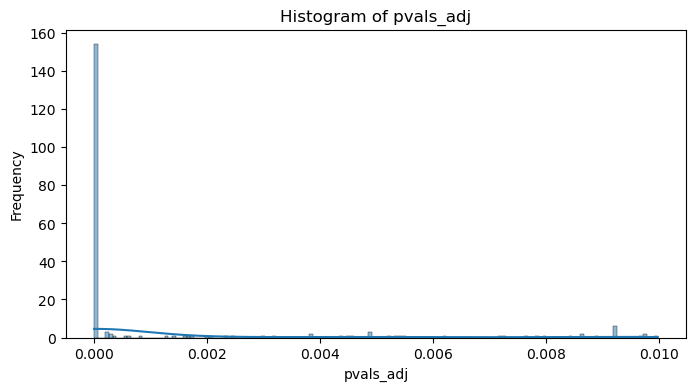

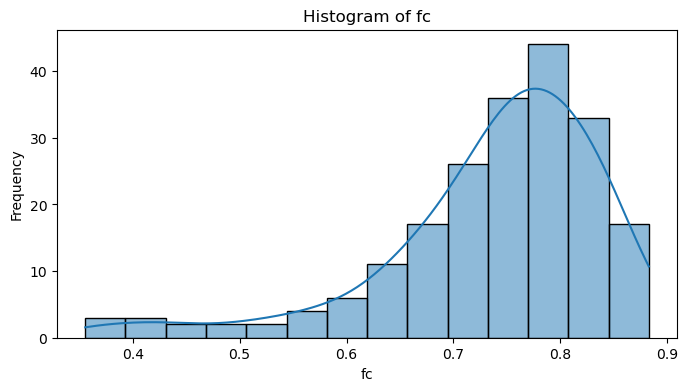

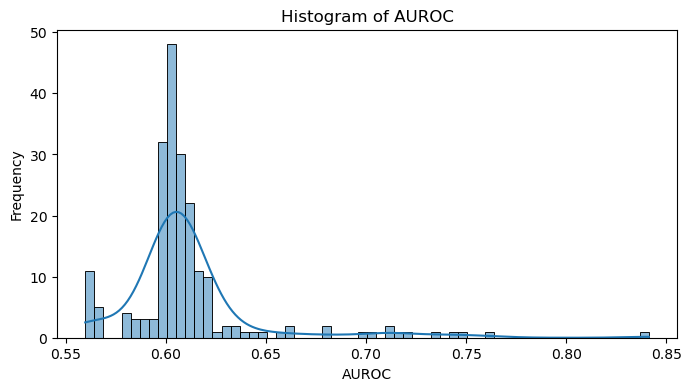

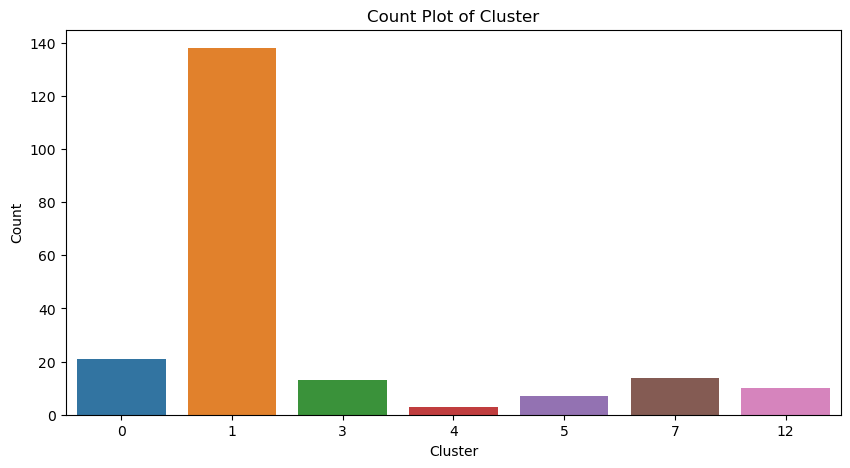

In [217]:
# Plot histograms for each numeric feature
for column in ['pvals_adj', 'fc', 'AUROC']:
    plt.figure(figsize=(8, 4))
    sns.histplot(filtered_dmg_table[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# Plot a count plot for the 'cluster' column since it's categorical
plt.figure(figsize=(10, 5))
sns.countplot(x='cluster', data=filtered_dmg_table)
plt.title('Count Plot of Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

In [52]:
conda install pytables

usage: conda [-h] [-V] command ...
conda: error: unrecognized arguments: pytables

Note: you may need to restart the kernel to use updated packages.


In [52]:
pip install tables

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 54.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 68.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.3/384.3 kB 44.1 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.
